# Random Forest Training

Train a stronger pixel-wise Random Forest baseline with richer spectral and texture features, then visualize one held-out test prediction.

In [57]:
from pathlib import Path

import joblib
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import rasterio as rio

from scipy.ndimage import maximum_filter, minimum_filter, uniform_filter
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import classification_report, confusion_matrix
from sklearn.model_selection import GroupShuffleSplit

ROOT = Path.cwd()
if not (ROOT / "data").exists():
    ROOT = ROOT.parent

DATA_DIR = ROOT / "data" / "samples_generated"
if not DATA_DIR.exists():
    DATA_DIR = ROOT / "data" / "samples_prepared"

MODEL_DIR = ROOT / "outputs" / "models"
MODEL_DIR.mkdir(parents=True, exist_ok=True)

CLASS_NAMES = {1: "Greenery", 2: "Sand", 3: "Water", 4: "Cement"}
CLASS_IDS = list(CLASS_NAMES)
TARGET_NAMES = [CLASS_NAMES[class_id] for class_id in CLASS_IDS]

COLORS = np.array([
    [0, 0, 0],
    [0, 100, 0],
    [184, 134, 11],
    [0, 0, 139],
    [105, 105, 105],
], dtype=np.uint8)

RANDOM_STATE = 42
MAX_PIXELS_PER_CLASS = 1500
TARGET_SAMPLE = "AlKhargaOasis"

RF_PARAMS = {
    "n_estimators": 120,
    "max_depth": 24,
    "min_samples_leaf": 2,
    "class_weight": "balanced_subsample",
    "n_jobs": -1,
    "random_state": RANDOM_STATE,
}

DATA_DIR


PosixPath('/mnt/windows_data/CUFE/Fourth Year/Second Semester/Satellite_Imagery/Project_v2/data/samples_generated')

In [58]:
def clean_mask(mask, edge_size=3):
    clean = mask.copy()
    noisy_edge = maximum_filter(clean, size=edge_size) != minimum_filter(clean, size=edge_size)
    clean[(~np.isin(clean, CLASS_IDS)) | noisy_edge] = 0
    return clean


def scale_input(spectral):
    return np.clip(spectral / 10000.0, 0, 1)


def load_sample(row):
    with rio.open(row.spectral_path) as src:
        spectral = scale_input(src.read().astype("float32"))

    with rio.open(row.mask_path) as src:
        mask = clean_mask(src.read(1).astype("uint8"))

    return spectral, mask


def norm_diff(a, b):
    return (a - b) / (a + b + 1e-6)


def local_stats(image, size=5):
    mean = uniform_filter(image, size=size, mode="nearest")
    sq_mean = uniform_filter(image * image, size=size, mode="nearest")
    std = np.sqrt(np.clip(sq_mean - mean * mean, 0, None))
    return mean, std


def add_features(spectral):
    bands = np.moveaxis(spectral, 0, -1)
    b2, b3, b4 = bands[..., 1], bands[..., 2], bands[..., 3]
    b8, b11 = bands[..., 7], bands[..., 10]

    ndvi = norm_diff(b8, b4)
    ndwi = norm_diff(b3, b8)
    mndwi = norm_diff(b3, b11)
    ndbi = norm_diff(b11, b8)
    bsi = ((b11 + b4) - (b8 + b2)) / ((b11 + b4) + (b8 + b2) + 1e-6)

    features = [
        bands,
        ndvi[..., None],
        ndwi[..., None],
        mndwi[..., None],
        ndbi[..., None],
        bsi[..., None],
    ]

    for layer in [ndvi, mndwi, ndbi, b11]:
        mean, std = local_stats(layer)
        features.extend([mean[..., None], std[..., None]])

    return np.dstack(features).astype("float32")


def rgb_preview(spectral):
    rgb = np.moveaxis(spectral[[3, 2, 1]], 0, -1)
    low = np.percentile(rgb, 2, axis=(0, 1), keepdims=True)
    high = np.percentile(rgb, 98, axis=(0, 1), keepdims=True)
    return np.clip((rgb - low) / (high - low + 1e-6), 0, 1)


def colorize(mask):
    return COLORS[mask]


def predict_scene(model, spectral):
    features = add_features(spectral)
    height, width, feature_count = features.shape
    pred = model.predict(features.reshape(-1, feature_count))
    return pred.reshape(height, width).astype("uint8")


def build_training_set(frame, max_per_class_per_image=MAX_PIXELS_PER_CLASS):
    rng = np.random.default_rng(RANDOM_STATE)
    xs, ys = [], []

    for row in frame.itertuples(index=False):
        spectral, mask = load_sample(row)
        features = add_features(spectral)
        flat_features = features.reshape(-1, features.shape[-1])
        labels = mask.reshape(-1)

        for class_id in CLASS_IDS:
            class_pixels = np.flatnonzero(labels == class_id)
            if len(class_pixels) == 0:
                continue

            take = min(max_per_class_per_image, len(class_pixels))
            picked_pixels = rng.choice(class_pixels, size=take, replace=False)

            xs.append(flat_features[picked_pixels])
            ys.append(np.full(take, class_id, dtype=np.uint8))

    return np.vstack(xs), np.concatenate(ys)


def evaluate_model(model, frame):
    cm = np.zeros((len(CLASS_IDS), len(CLASS_IDS)), dtype=np.int64)
    y_true, y_pred = [], []

    for row in frame.itertuples(index=False):
        spectral, mask = load_sample(row)
        pred = predict_scene(model, spectral)
        valid = mask > 0

        cm += confusion_matrix(mask[valid], pred[valid], labels=CLASS_IDS)
        y_true.append(mask[valid].reshape(-1))
        y_pred.append(pred[valid].reshape(-1))

    intersection = np.diag(cm)
    union = cm.sum(axis=1) + cm.sum(axis=0) - intersection
    iou = intersection / np.maximum(union, 1)

    metrics = pd.DataFrame({
        "class_id": CLASS_IDS,
        "class_name": TARGET_NAMES,
        "IoU": iou,
        "support": cm.sum(axis=1),
    })

    report = classification_report(
        np.concatenate(y_true),
        np.concatenate(y_pred),
        labels=CLASS_IDS,
        target_names=TARGET_NAMES,
        zero_division=0,
    )

    return metrics, report


In [59]:
records = []

for spectral_path in sorted(DATA_DIR.glob("*/*_Spectral.tif")):
    sample = spectral_path.parent.name
    mask_path = spectral_path.with_name(f"{sample}_Mask.tif")

    if mask_path.exists():
        records.append({
            "sample": sample,
            "spectral_path": spectral_path,
            "mask_path": mask_path,
        })

samples = pd.DataFrame.from_records(records)
if samples.empty:
    raise FileNotFoundError(f"No paired spectral/mask files found in {DATA_DIR}")

samples


,sample,spectral_path,mask_path
0,6thOfOctoberCity,/mnt/windows_data/CUFE/Fourth Year/Second Seme...,/mnt/windows_data/CUFE/Fourth Year/Second Seme...
1,AbuSimbel,/mnt/windows_data/CUFE/Fourth Year/Second Seme...,/mnt/windows_data/CUFE/Fourth Year/Second Seme...
2,AinSokhna,/mnt/windows_data/CUFE/Fourth Year/Second Seme...,/mnt/windows_data/CUFE/Fourth Year/Second Seme...
3,AlKhargaOasis,/mnt/windows_data/CUFE/Fourth Year/Second Seme...,/mnt/windows_data/CUFE/Fourth Year/Second Seme...
4,Alexandria,/mnt/windows_data/CUFE/Fourth Year/Second Seme...,/mnt/windows_data/CUFE/Fourth Year/Second Seme...
5,AswanHighDam,/mnt/windows_data/CUFE/Fourth Year/Second Seme...,/mnt/windows_data/CUFE/Fourth Year/Second Seme...
6,Asyut,/mnt/windows_data/CUFE/Fourth Year/Second Seme...,/mnt/windows_data/CUFE/Fourth Year/Second Seme...
7,BahariyaOasis,/mnt/windows_data/CUFE/Fourth Year/Second Seme...,/mnt/windows_data/CUFE/Fourth Year/Second Seme...
8,BenbanSolarPark,/mnt/windows_data/CUFE/Fourth Year/Second Seme...,/mnt/windows_data/CUFE/Fourth Year/Second Seme...
9,BeniSuef,/mnt/windows_data/CUFE/Fourth Year/Second Seme...,/mnt/windows_data/CUFE/Fourth Year/Second Seme...


In [60]:
splitter = GroupShuffleSplit(n_splits=1, test_size=0.25, random_state=RANDOM_STATE)
train_idx, test_idx = next(splitter.split(samples, groups=samples["sample"]))

train_df = samples.iloc[train_idx].reset_index(drop=True)
test_df = samples.iloc[test_idx].reset_index(drop=True)

print(f"train scenes: {len(train_df)}")
print(train_df["sample"].tolist())
print()
print(f"test scenes: {len(test_df)}")
print(test_df["sample"].tolist())


train scenes: 32
['6thOfOctoberCity', 'AbuSimbel', 'AinSokhna', 'AswanHighDam', 'BahariyaOasis', 'BeniSuef', 'CairoUniv', 'DakhlaOasis', 'EastPortSaidPort', 'Edfu', 'ElAlamein', 'ElGouna', 'Farafra', 'GreatPyramidOfGiza', 'HawaraFayoum', 'Hurghada', 'IconicTower', 'KarnakLuxor', 'KomOmbo', 'Mallawi', 'MarsaAlam', 'MarsaMatrouh', 'Minya', 'NagHammadi', 'NewAlamein', 'NewCairo', 'PhilaeAswan', 'RasMuhammadNationalPark', 'SharqElOwainat', 'SuezPort', 'WadiElNatrun', 'Zagazig']

test scenes: 11
['AlKhargaOasis', 'Alexandria', 'Asyut', 'BenbanSolarPark', 'Damietta', 'LakeBurullus', 'LakeManzala', 'Qena', 'RashidRosetta', 'SaintCatherine', 'SiwaOasis']


In [61]:
X_train, y_train = build_training_set(train_df)

print(f"training pixels: {len(y_train):,}")
print(f"feature count: {X_train.shape[1]}")

pd.Series(y_train).map(CLASS_NAMES).value_counts().rename_axis("class").to_frame("pixels")


training pixels: 120,891
feature count: 25


,pixels
class,
Sand,41117
Cement,28573
Greenery,26785
Water,24416


In [62]:
model = RandomForestClassifier(**RF_PARAMS)
model.fit(X_train, y_train)

model_path = MODEL_DIR / "random_forest_baseline.joblib"
joblib.dump(model, model_path)

model_path


PosixPath('/mnt/windows_data/CUFE/Fourth Year/Second Semester/Satellite_Imagery/Project_v2/outputs/models/random_forest_baseline.joblib')

In [63]:
metrics, report = evaluate_model(model, test_df)

print(f"mIoU: {metrics['IoU'].mean():.3f}")
display(metrics.sort_values("class_id"))
print()
print("Classification report")
print(report)


mIoU: 0.912


,class_id,class_name,IoU,support
0,1,Greenery,0.874103,122591
1,2,Sand,0.920885,199427
2,3,Water,0.980297,110295
3,4,Cement,0.872023,203956



Classification report
              precision    recall  f1-score   support

    Greenery       0.93      0.94      0.93    122591
        Sand       0.94      0.98      0.96    199427
       Water       0.99      0.99      0.99    110295
      Cement       0.95      0.91      0.93    203956

    accuracy                           0.95    636269
   macro avg       0.95      0.95      0.95    636269
weighted avg       0.95      0.95      0.95    636269



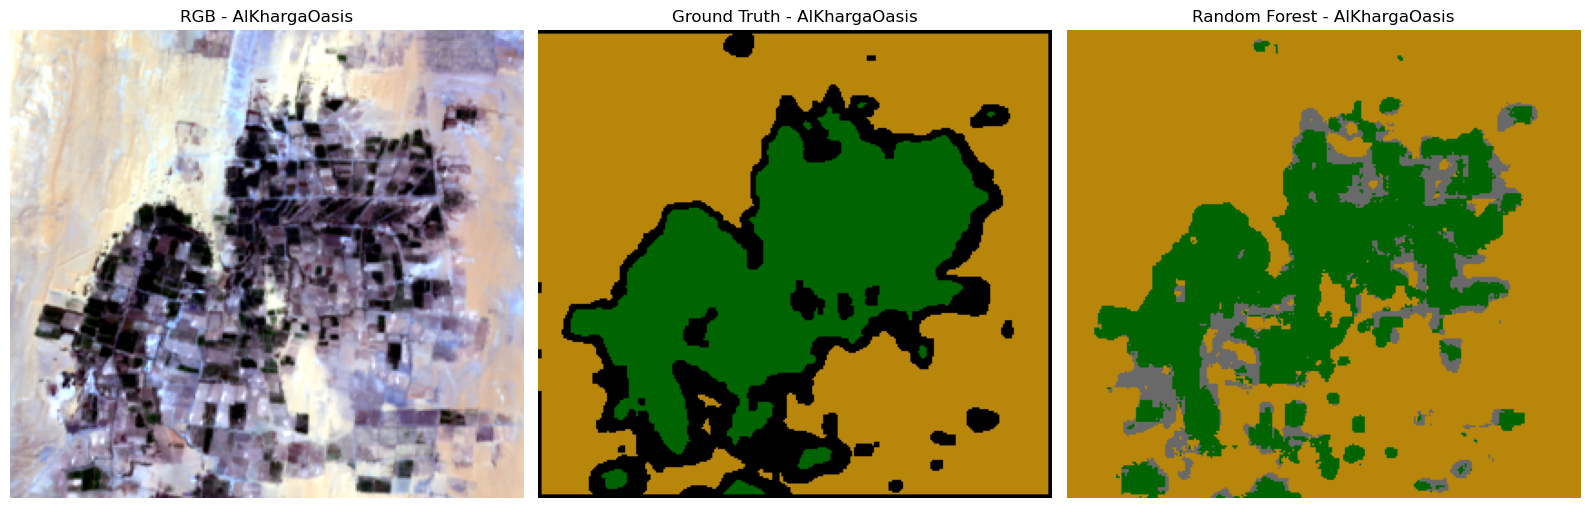

In [65]:
row = next(samples[samples["sample"].eq(TARGET_SAMPLE)].itertuples(index=False), None)
if row is None:
    raise ValueError(f"{TARGET_SAMPLE} not found in samples")

spectral, mask = load_sample(row)
pred = predict_scene(model, spectral)

fig, axes = plt.subplots(1, 3, figsize=(16, 5))

axes[0].imshow(rgb_preview(spectral))
axes[0].set_title(f"RGB - {row.sample}")

axes[1].imshow(colorize(mask))
axes[1].set_title(f"Ground Truth - {row.sample}")

axes[2].imshow(colorize(pred))
axes[2].set_title(f"Random Forest - {row.sample}")

for ax in axes:
    ax.axis("off")

plt.tight_layout()
plt.show()


In [68]:
best_row = metrics.loc[metrics["IoU"].idxmax()]
worst_row = metrics.loc[metrics["IoU"].idxmin()]

print("Discussion")
print(
    f"Random Forest used {len(train_df)} train scenes, {len(test_df)} test scenes, "
    f"{len(y_train):,} sampled pixels and {X_train.shape[1]} features."
)
print(
    f"Final mIoU = {metrics['IoU'].mean():.3f}. "
    f"Best class: {best_row['class_name']} ({best_row['IoU']:.3f}). "
    f"Weakest class: {worst_row['class_name']} ({worst_row['IoU']:.3f})."
)
print(
    "This model is fast and stable, but mixed boundaries are still the hardest part."
)


Discussion
Random Forest used 32 train scenes, 11 test scenes, 120,891 sampled pixels and 25 features.
Final mIoU = 0.912. Best class: Water (0.980). Weakest class: Cement (0.872).
This model is fast and stable, but mixed boundaries are still the hardest part.
